# Project 2: Exploratory Data Analysis (EDA)
## E-Commerce Sales Dataset

---

### Objective
To explore and analyze the cleaned e-commerce dataset in order to 
uncover patterns, trends, distributions, and business insights 
that can support data-driven decision making.

---

### Dataset
- **Source:** DecodesLab Internship — Project 2
- **Input:** Cleaned dataset from Project 1
- **Rows:** ~1200 | **Columns:** 14
- **Format:** Excel (.xlsx)

---

### Approach
This analysis follows the IPO Framework:
- **Input:** Cleaned e-commerce data
- **Process:** Statistical analysis & visualization
- **Output:** Actionable business insights

---

### Key Note
During Project 1 validation, it was found that discount and coupon 
codes had no effect on the final recorded TotalPrice 
(Quantity × UnitPrice = TotalPrice in 100% of cases).
This will be investigated as a key business observation.

---

### Tools Used
- Python, Pandas, Matplotlib, Seaborn

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df=pd.read_excel('cleaned_dataset.xlsx')

## Inspection

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,calculated
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Other,Shipped,TRK91186779,3,SAVE10,Other,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Other,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


In [5]:
df.shape

(1200, 15)

In [6]:
df.columns.tolist()

['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'Quantity',
 'UnitPrice',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'ItemsInCart',
 'CouponCode',
 'ReferralSource',
 'TotalPrice',
 'calculated']

In [7]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
calculated                float64
dtype: object

In [8]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
calculated           0
dtype: int64

In [9]:
df.drop(columns=['calculated'], inplace=True)

In [10]:
df.shape

(1200, 14)

### Dataset Overview
- 1200 orders, 14 columns after dropping validation column
- All data types are correct
- Only CouponCode has missing values (309 nulls = ~26%) 
- This is expected as not all customers use coupons

## Step 3: Descriptive Statistics
Understanding the central tendency and spread of numerical columns.

In [11]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [12]:
df.describe(include='object')

C:\Users\hp\AppData\Local\Temp\ipykernel_13780\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,OrderID,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,891,1200
unique,1200,1189,7,655,5,5,1200,3,5
top,ORD200000,C98474,Printer,533 Main St,Other,Cancelled,TRK37947903,FREESHIP,Instagram
freq,1,2,181,8,258,250,1,313,259


## Descriptive Statistics — Key Observations

### Numerical Columns
- **TotalPrice** is right-skewed (Mean: 1053.97 > Median: 823.61), 
  indicating a small segment of high-value customers inflating the average.
  Median (823.61) is the more reliable measure for typical order value.
- **Quantity and UnitPrice** are normally distributed, 
  mean and median are almost equal.
- **TotalPrice std (819.85)** is almost equal to the mean, 
  indicating customers are buying in very different amounts.

### Categorical Columns
- **11 customers placed repeat orders** — loyalty segment worth investigating.
- **Printer is the top-selling product** (181/1200 = ~15%) — 
  high dependency on a single product is a business risk.
- **~21% cancellation rate** (250/1200) — alarming for business, 
  reason needs to be investigated.
- **PaymentMethod "Other" is most common** (258/1200) — 
  suggests better payment categorization needed in data collection.
- **FREESHIP is the most used coupon** (313 times) however 
  coupon codes show no impact on TotalPrice — needs business clarification.
- **Instagram drives most traffic** (259/1200 = ~22%) — 
  strongest marketing channel.

### 5-Number Summary Insight
df.describe() confirms TotalPrice spread:

Min: 11.39 | Q1: 410.52 | Median: 823.61 | Q3: 1578.47 | Max: 3456.40

## Step 4: Univariate Analysis
Analyzing each column individually to understand 
its distribution, spread, and patterns.

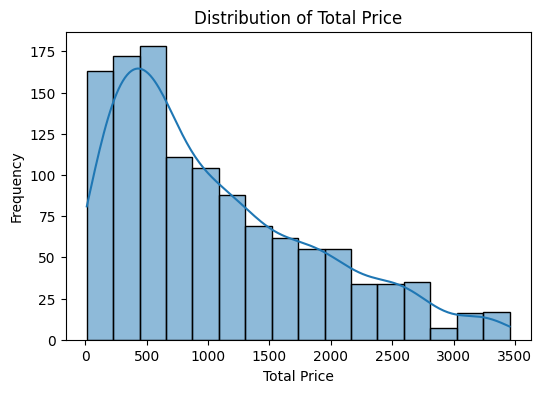

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(data=df,x='TotalPrice',kde=True)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

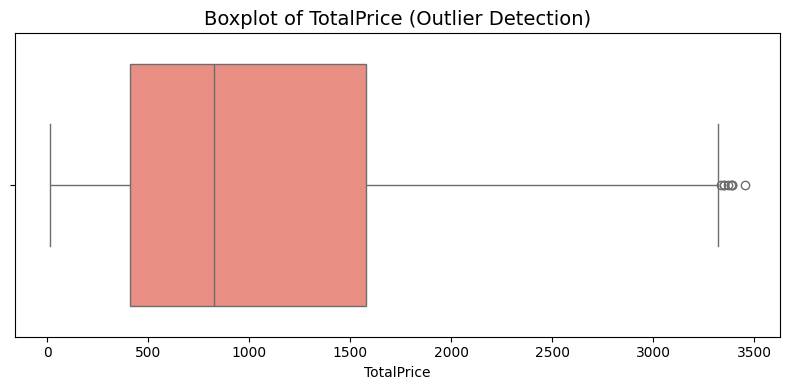

In [14]:

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalPrice'], color='salmon')
plt.title('Boxplot of TotalPrice (Outlier Detection)', fontsize=14)
plt.xlabel('TotalPrice')
plt.tight_layout()
plt.show()

## Univariate Analysis — TotalPrice

### Distribution (Histogram)
- TotalPrice is **right-skewed** — majority of orders 
  cluster around lower-medium values
- A small segment of high-value orders creates a 
  long right tail
- **Median (823.61) is more reliable** than mean (1053.97) 
  as the typical order value

### Outlier Detection (Boxplot)
- **IQR Range:** Q1 (~450) to Q3 (~1580)
- Median line is shifted towards left side of box, 
  confirming right skew
- Long right whisker indicates **high price spread** 
  across customers
- **2-3 outlier dots** detected around 3300-3500 range

### Business Insight
- These outliers are likely **VIP customers or bulk orders**
  — real business signals worth investigating
- Majority of customers spend between 450-1580 per order
- A small high-value segment significantly inflates 
  the average order value
- **Marketing strategy should target the median customer 
  (823) not the mean (1053)**

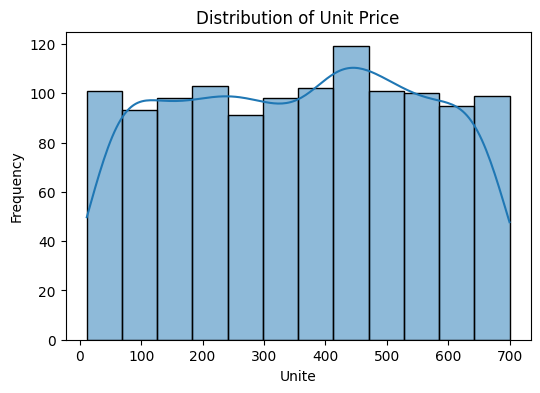

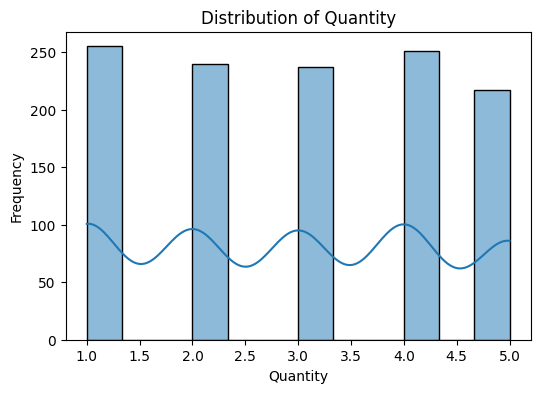

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(data=df,x='UnitPrice',kde=True)
plt.title("Distribution of Unit Price")
plt.xlabel("Unite")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df,x='Quantity',kde=True)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

## Univariate Analysis — UnitPrice & Quantity

### UnitPrice (Histogram)
- Nearly **normally distributed** with most prices 
  clustered around 100-700 range
- No significant skew detected
- Confirms describe() findings — mean and median are close

### Quantity (Histogram)
- **Uniformly distributed** across values 1 to 5
- Customers order in small quantities consistently
- No extreme bulk ordering detected

### Business Insight
- Products are mostly low-medium priced items
- Customers prefer ordering small quantities 
  rather than bulk
- High TotalPrice outliers are likely driven by 
  **UnitPrice not Quantity**

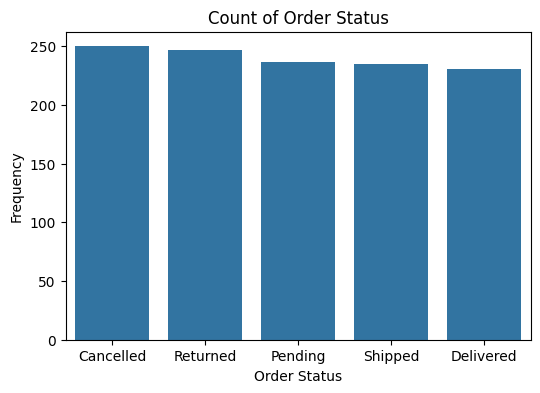

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='OrderStatus',
              order=df['OrderStatus'].value_counts().index)
plt.title("Count of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Frequency")
plt.show()

## Univariate Analysis — OrderStatus

### Distribution (Countplot)
- All 5 order statuses are **almost equally distributed** 
  (~230-252 orders each)
- This uniform distribution is itself a **red flag**

### Status Breakdown:
| Status | Count | % |
|---|---|---|
| Cancelled | ~252 | ~21% |
| Returned | ~248 | ~21% |
| Pending | ~238 | ~20% |
| Shipped | ~235 | ~20% |
| Delivered | ~230 | ~19% |

### Business Insight 🚨
- Only **~19% of orders are successfully delivered**
- Cancelled + Returned = **~42% of all orders**
- For every 5 orders placed, only 1 reaches 
  the customer successfully
- This represents a **massive revenue loss and 
  customer satisfaction crisis**
- Possible reasons: product quality, pricing, 
  delivery issues — needs deeper investigation

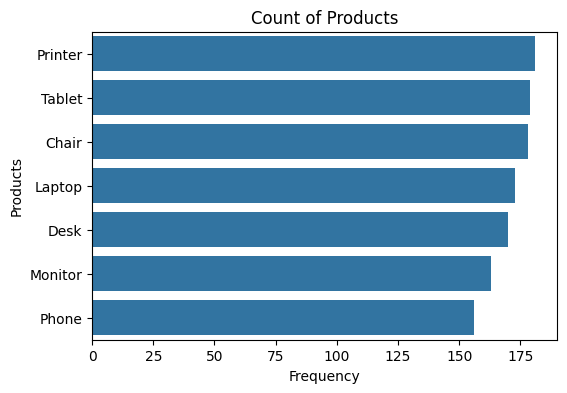

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, y='Product',
              order=df['Product'].value_counts().index)
plt.title("Count of Products")
plt.xlabel("Frequency")
plt.ylabel("Products")
plt.show()


## Univariate Analysis — Product

### Distribution (Countplot)
- 7 unique products, all fairly evenly distributed
- **Printer is top-selling product** — highest frequency
- **Phone is lowest-selling product**
- No single product dominates heavily

### Business Insight
- Relatively balanced product portfolio
- Printer leading but gap is not dramatic
- Phone needs **marketing attention** or 
  reconsideration of stock levels

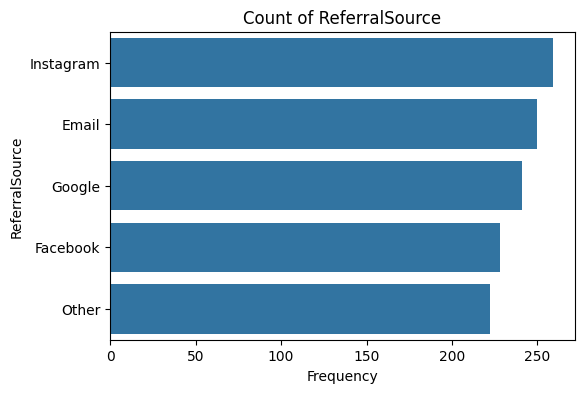

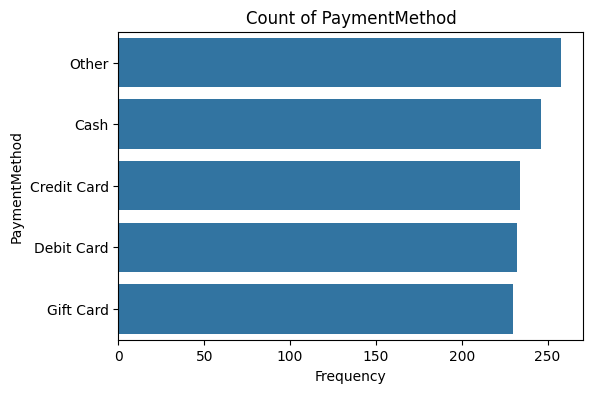

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, y='ReferralSource',
              order=df['ReferralSource'].value_counts().index)
plt.title("Count of ReferralSource")
plt.xlabel("Frequency")
plt.ylabel("ReferralSource")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, y='PaymentMethod',
              order=df['PaymentMethod'].value_counts().index)
plt.title("Count of PaymentMethod")
plt.xlabel("Frequency")
plt.ylabel("PaymentMethod")
plt.show()


## Univariate Analysis — ReferralSource & PaymentMethod

### ReferralSource (Countplot)
- 5 referral sources, all fairly evenly distributed
- **Instagram is the top referral source** — strongest 
  marketing channel
- **"Other" is the lowest** referral source
- No single source dramatically dominates

### Business Insight
- Instagram should be **priority marketing platform**
- Even distribution suggests diversified traffic sources
- "Other" category needs better tracking/categorization

---

### PaymentMethod (Countplot)
- 5 payment methods, all fairly evenly distributed
- **"Other" is the most used** payment method
- **Gift Card is the least used** payment method
- Similar to ReferralSource — no dramatic dominance

### Business Insight
- "Other" dominating payment method suggests 
  **data collection needs improvement**
- Gift Card program is **underutilized** — 
  opportunity for promotion
- Diverse payment methods suggest healthy 
  payment infrastructure

## Step 5: Bivariate Analysis
Analyzing relationships between two columns to 
uncover deeper business insights.

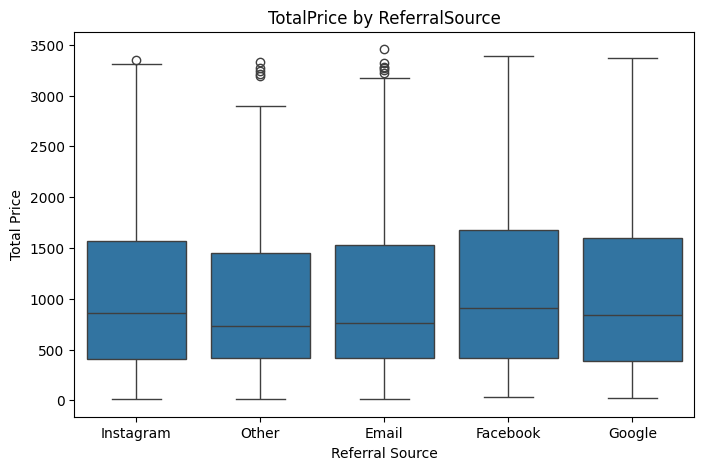

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='ReferralSource', y='TotalPrice')
plt.title("TotalPrice by ReferralSource")
plt.xlabel("Referral Source")
plt.ylabel("Total Price")
plt.show()

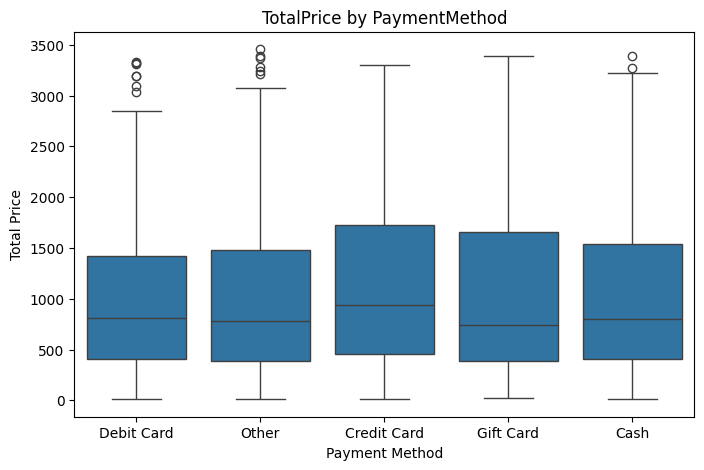

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='PaymentMethod', y='TotalPrice')
plt.title("TotalPrice by PaymentMethod")
plt.xlabel("Payment Method")
plt.ylabel("Total Price")
plt.show()

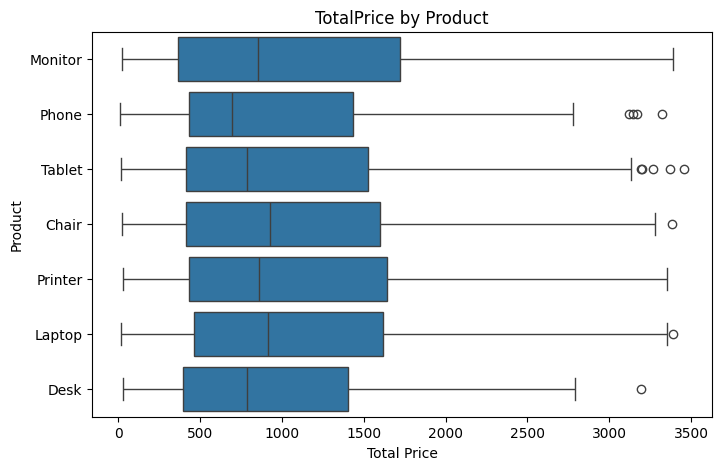

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='Product', x='TotalPrice')
plt.title("TotalPrice by Product")
plt.xlabel("Total Price")
plt.ylabel("Product")
plt.show()

## Bivariate Analysis

### ReferralSource vs TotalPrice
- **Facebook customers spend the most** despite 
  Instagram having more visitors
- Instagram drives volume but not highest value orders
- All sources show similar spread with outliers present

### PaymentMethod vs TotalPrice
- **Credit Card users are highest spenders** 
  (median ~1000+)
- Debit Card users spend least per order
- Payment method shows mild influence on order value

### Product vs TotalPrice
- **Monitor generates highest revenue** per order
- Desk and Phone produce lowest order values
- Printer is top selling but not highest revenue generator

### Key Business Insight
- Focus premium marketing on **Facebook + Credit Card** 
  customer segment — highest value customers
- **Instagram strategy** should focus on 
  upselling, not just traffic
- **Monitor** should be highlighted in promotions 
  despite Printer being top seller

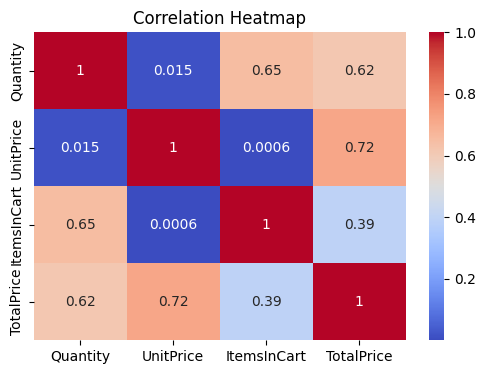

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Quantity','UnitPrice',
                'ItemsInCart','TotalPrice']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis — Heatmap

### Key Correlations with TotalPrice:
| Pair | Correlation | Strength |
|---|---|---|
| UnitPrice vs TotalPrice | 0.72 | Strong |
| Quantity vs TotalPrice | 0.62 | Strong |
| ItemsInCart vs TotalPrice | 0.39 | Weak |
| UnitPrice vs ItemsInCart | 0.0006 | None |

### Business Insights:
- **UnitPrice is the strongest driver of TotalPrice** 
  — premium products directly boost revenue
- **Quantity also strongly affects TotalPrice** 
  — bulk buying drives higher bills
- **ItemsInCart weakly affects TotalPrice** 
  — customers browse more than they buy
- **UnitPrice has no relation to ItemsInCart** 
  — customers explore regardless of price point

### Key Takeaway:
- Focus on **premium product pricing strategy** 
  to increase revenue
- Introduce **bundle offers** to convert 
  cart items into actual purchases
- Correlation ≠ Causation — these are 
  patterns, not guarantees

## Executive Summary

### Problem Statement
Analyze a cleaned e-commerce dataset to uncover 
patterns, trends, and business insights that can 
support data-driven decision making.

### Methodology
- Univariate Analysis: Distribution and outlier 
  detection for each column
- Bivariate Analysis: Relationships between 
  key business variables
- Correlation Analysis: Numerical relationships 
  across all numeric columns

### Key Findings
1. **TotalPrice is right-skewed** — typical order 
   value is 823 (median), not 1053 (mean)
2. **Only 19% of orders are delivered** — 
   Cancelled + Returned = 42% of all orders 🚨
3. **Facebook customers spend most** despite 
   Instagram driving most traffic
4. **Credit Card users are highest spenders** 
   among all payment methods
5. **UnitPrice is strongest revenue driver** 
   (correlation 0.72 with TotalPrice)
6. **Monitor generates highest revenue** despite 
   Printer being top seller by volume
7. **Coupon codes show zero price impact** — 
   discount system needs investigation
8. **Cart-to-purchase gap exists** — ItemsInCart 
   weakly correlates with TotalPrice (0.39)

### Recommendations
1. Investigate 42% cancellation/return rate urgently
2. Shift marketin